In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/UCI_Credit_Card.csv')

df = df.rename(columns={'default.payment.next.month': 'target'})

print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Data Loaded: 30000 rows, 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Overall Default Rate: 22.12%


,PAY_0,Total_Customers,Default_Rate
0,-2,2759,0.132294
1,-1,5686,0.167781
2,0,14737,0.128113
3,1,3688,0.339479
4,2,2667,0.691414
5,3,322,0.757764
6,4,76,0.684211
7,5,26,0.500000
8,6,11,0.545455
9,7,9,0.777778


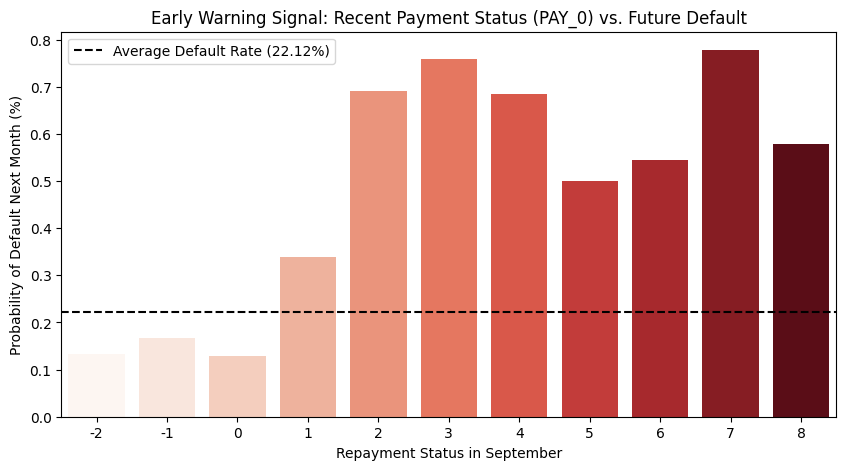

In [ ]:

overall_bad_rate = df['target'].mean()
print(f"Overall Default Rate: {overall_bad_rate:.2%}")


pay_status_analysis = df.groupby('PAY_0').agg(
    Total_Customers=('target', 'count'),
    Default_Rate=('target', 'mean')
).reset_index()

display(pay_status_analysis)

plt.figure(figsize=(10, 5))
sns.barplot(x='PAY_0', y='Default_Rate', data=pay_status_analysis, palette='Reds', hue='PAY_0', legend=False)

plt.axhline(overall_bad_rate, color='black', linestyle='--', label=f'Average Default Rate ({overall_bad_rate:.2%})')

plt.title('Early Warning Signal: Recent Payment Status (PAY_0) vs. Future Default')
plt.xlabel('Repayment Status in September')
plt.ylabel('Probability of Default Next Month (%)')
plt.legend()
plt.show()

In [ ]:
from numpy.random.mtrand import f
# Epsilon is added to avoid division by zero errors
epsilon = 1e-6

#Calcluate payment ratio
for i in range(1, 7):
  df[f'PAY_RATIO_{i}'] = df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'] + epsilon)
  #clip outliers
  df[f'PAY_RATIO_{i}'] = df[f'PAY_RATIO_{i}'].clip(lower=0, upper=1)

df['AVG_PAY_RATIO'] = df[[f'PAY_RATIO_{i}' for i in range(1,7)]].mean(axis=1)

#calculate credit utilization and trend
for i in range(1,7):
  df[f'UTIL_{i}'] = df[f'BILL_AMT{i}'] / df['LIMIT_BAL']


df[f'UTIL_{i}'] = df[[f'UTIL_{i}' for i in range(1, 7)]].mean(axis=1)

df['UTIL_TREND'] = df['UTIL_1'] - df['UTIL_6']


pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

df['MAX_DLQ'] = df[pay_cols].max(axis=1)
print(f"Dataframe shape: {df.shape[0]} rows, {df.shape[1]} columns")

df['PAY_RATIO_BIN'] = pd.qcut(df['AVG_PAY_RATIO'],  q=5, duplicates='drop')

ratio_analysis = df.groupby('PAY_RATIO_BIN', observed=False).agg(
    Total_Customers=('target', 'count'),
    Default_Rate=('target', 'mean')
).reset_index()

display(ratio_analysis)

Dataframe shape: 30000 rows, 40 columns


,PAY_RATIO_BIN,Total_Customers,Default_Rate
0,"(-0.001, 0.0383]",6000,0.298000
1,"(0.0383, 0.0565]",6000,0.253167
2,"(0.0565, 0.172]",6000,0.252333
3,"(0.172, 0.477]",6000,0.163167
4,"(0.477, 1.0]",6000,0.139333


In [ ]:
df['TREND_BIN'] = pd.qcut(df['UTIL_TREND'], q=4, duplicates='drop')
print(df.groupby('TREND_BIN')['target'].mean())

TREND_BIN
(-1.547, -0.0198]     0.279733
(-0.0198, 0.00166]    0.233733
(0.00166, 0.0885]     0.173600
(0.0885, 3.191]       0.197733
Name: target, dtype: float64


/tmp/ipykernel_1578/2308935029.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('TREND_BIN')['target'].mean())


In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
import joblib

In [ ]:
# Drop non-predictive columns and the target
cols_to_drop = ['ID', 'target', 'PAY_RATIO_BIN', 'TREND_BIN']
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {X_train.shape[0]} customers. Testing on {X_test.shape[0]}.")

Training on 24000 customers. Testing on 6000.


In [ ]:
#scale_pos_weight = count(negative examples) / count(positive examples)
imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

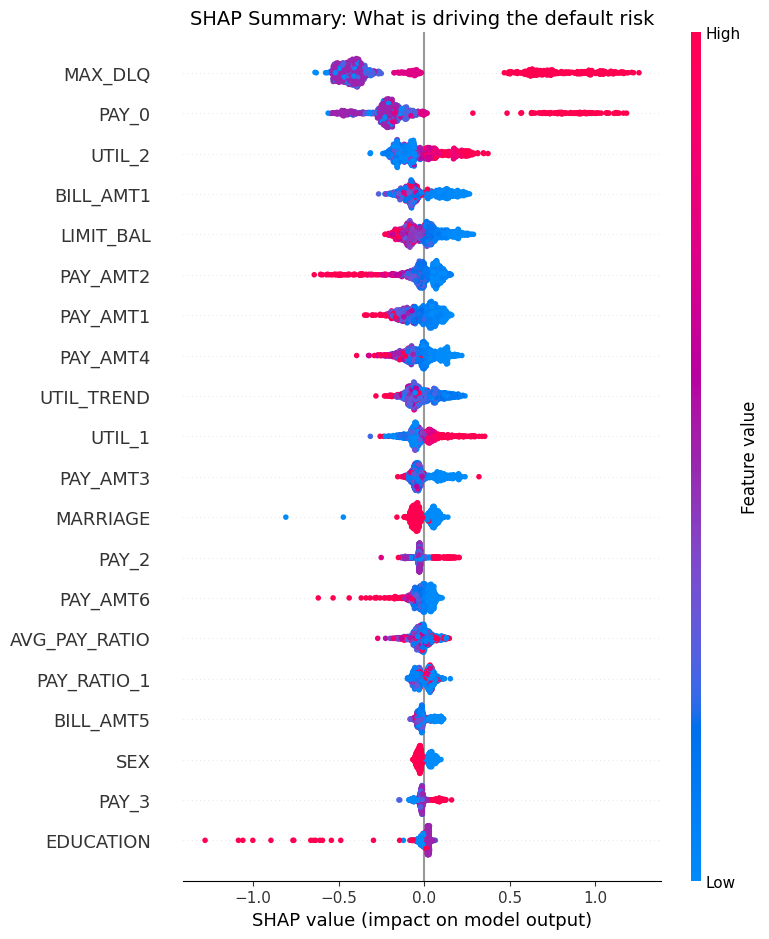

In [ ]:
X_test_sample = X_test.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: What is driving the default risk", fontsize=14)
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.show()

In [ ]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

strategy_df = pd.DataFrame({
    'Actual_Default': y_test,
    'Predicted_Prob': y_pred_proba
})

def assign_treatment(prob):
  if prob >= 0.60:
    return 'Phone_Call'
  elif prob >= 0.30:
    return 'SMS_Reminder'
  else:
    return 'No_Action'

strategy_df['Treatment'] = strategy_df['Predicted_Prob'].apply(assign_treatment)

treatment_counts = strategy_df['Treatment'].value_counts().sort_index()
display(treatment_counts)

,count
Treatment,
No_Action,2240
Phone_Call,1368
SMS_Reminder,2392


In [ ]:
# cost in $ Dolar
cost_per_call = 10
cost_per_sms = 0.10
loss_per_default = 1000
call_success_rate = 0.30
sms_success_rate = 0.10

#calculate baseline
total_actual_defaults = strategy_df['Actual_Default'].sum()
baseline_loss = total_actual_defaults * loss_per_default

print(f"Baseline loss: ${baseline_loss:,.2f}")

saved_by_calls = strategy_df[(strategy_df['Treatment'] == 'Phone_Call') & (strategy_df['Actual_Default'] == 1)].shape[0] * call_success_rate * loss_per_default
cost_of_calls = strategy_df[strategy_df['Treatment'] == 'Phone_Call'].shape[0] * cost_per_call

saved_by_sms = strategy_df[(strategy_df['Treatment'] == 'SMS_Reminder') & (strategy_df['Actual_Default'] == 1)].shape[0] * sms_success_rate * loss_per_default
cost_of_sms = strategy_df[strategy_df['Treatment'] == 'SMS_Reminder'].shape[0] * cost_per_sms

net_savings = (saved_by_calls - cost_of_calls) + (saved_by_sms - cost_of_sms)

print(f"Total Cost of Operations (Calls + SMS): ${cost_of_calls + cost_of_sms}")
print(f"Total Money Saved: ${saved_by_calls + saved_by_sms:,.2f}")
print(f"NET FINANCIAL BENEFIT OF EWS: ${net_savings:,.2f}")

Baseline loss: $1,313,000.00
Total Cost of Operations (Calls + SMS): $13919.2
Total Money Saved: $260,800.00
NET FINANCIAL BENEFIT OF EWS: $246,880.80


In [ ]:
joblib.dump(xgb_model, 'xgb_model.pkl')

df_sample = df.sample(n=100, random_state=42)
df_sample.to_csv('customer_database.csv', index=False)